<a href="https://colab.research.google.com/github/niedrev/Well-being-project/blob/main/Big_Data_Report_TSI_St83814.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Title: Big Data Analysis and Implementation for Enhancing Employee Well-being in organisations

Module Code: UFCEE1-12-M

Module Title: Big Data [TSI]

Student Name: Vija Niedre

Student ID: ST83814

Submission Date:

##Table of Contents

Introduction

Methodology

*   Data Selection
*   Setup in Google Colab
*   Data Loading and Exploration

Analysis


*   Business Requirements Understanding
*   Data Extraction Techniques

Design


*   Data Quality Improvement Strategies
*   Ontology Generation

Implementation


*   Big Data Management with Dask
*   Cloud Computing Integration
*   Addressing Privacy and Trust

Results and Discussion

Conclusion

References

Appendices (if any)


##Introduction

**Brief Overview**

The project focuses on analyzing employee wellbeing using historical feedback data collected in a real organizational setting. Employee wellbeing is critical for fostering productivity, satisfaction, and retention within companies. The actual dataset, collected in 2019 and 2020, includes structured and unstructured feedback from employees, such as satisfaction ratings, workload metrics, and open-ended textual responses.


**Business Problem**

The objective is to identify the factors contributing to employee dissatisfaction and recommend actionable strategies to improve workplace wellbeing. By understanding key drivers and patterns in the data, businesses can make informed/ data based decisions to enhance employee wellbeing.




**Objective**

The primary goals of this analysis are:

1.   Feature Identification - analyze the dataset to determine the most important features impacting employee well-being.
2.  Visualization - use tools like Matplotlib and Seaborn to explore relationships within the data, uncover trends, and highlight key insights.
3. Insight Generation - extract actionable insights from both structured and unstructured data to address areas of dissatisfaction.
4. Strategic Recommendations - propose evidence-based recommendations for improving workplace wellbeing based on analysis results.

These four objectives aim to support organizations in enchasing employee wellbeing and fostering a healthier and more productive work environment.

##Metadology

###Data Selection

*   Structured Data Source:
  * Format: .csv
  * Origin:
      * Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.
      
  * Attributes:
      * Employee ID (anonymized)
      * Department (anonymized)
      * Employee in department (numerical)
      * Year
      * Time spent in company (categorical)
      * 15 questions with answers (categorical)
          * 3 questions have answer hierarcy (categorical)
          * 1 question - Wellbeing Score (10 point Likert scale)
      * Volume: 980 KB.

      * Purpose: Provides structured tabular data, ideal for statistical analysis, aggregation, and visualization. This dataset enables comprehensive insights into employee demographics, well-being, and satisfaction.



*   Unstructured/Semi-Structured Data Source:

  *   Format: .json
  *   Origin: Comercial data collected in Company through surveys and feedback mechanisms, gathered by the author, anonymized.

  * Attributes:
      *   Employee ID (anonymized)
      *   Feedback Comments (unstructured text)

  * Volume: 246 KB.

  * Purpose: Facilitates hierarchical and relational analysis, particularly suited for Natural Language Processing (NLP) techniques and flexible querying. This data allows for deep insights into employee sentiment and textual feedback.

###Setup in Google Colab

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
!pip install rdflib
import dask.dataframe as dd
from cryptography.fernet import Fernet
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder for categorical features

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.4/562.4 kB 8.9 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


###Data Loading and Exploration

* **Structured Data**

In [ ]:
# Loading structured data
structured_data = pd.read_csv('/content/Wellbeing_Companies_Data_Structured.csv')

In [ ]:
# Data frame dimension
structured_data.shape

(60924, 8)

In [ ]:
# Short view on data
structured_data.head()

,Company name,Year,Respondent ID,Department,Employee in department,Your time in the company?,Question,Answer
0,Company A,2019.0,30001.0,Department 2,27,10 years and more,1. Are you satisfied with your workload?,Yes
1,Company A,2019.0,30002.0,No answer,No answer,Up until 1 year,1. Are you satisfied with your workload?,Yes
2,Company A,2019.0,30003.0,Department 2,27,10 years and more,1. Are you satisfied with your workload?,Yes
3,Company A,2019.0,30004.0,Department 2,27,5-10 years,1. Are you satisfied with your workload?,Yes
4,Company A,2019.0,30005.0,Department 11,4,1-5 years,1. Are you satisfied with your workload?,Yes


In [ ]:
# Check column data types and non-null values
print(structured_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60924 entries, 0 to 60923
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company name               3232 non-null   object 
 1   Year                       3232 non-null   float64
 2   Respondent ID              3232 non-null   float64
 3   Department                 3232 non-null   object 
 4   Employee in department     3232 non-null   object 
 5   Your time in the company?  3232 non-null   object 
 6   Question                   3232 non-null   object 
 7   Answer                     3232 non-null   object 
dtypes: float64(2), object(6)
memory usage: 3.7+ MB
None


In [ ]:
# Summary statistics for all numeric columns
print(structured_data.describe())

              Year  Respondent ID
count  3232.000000    3232.000000
mean   2019.524752   30051.000000
std       0.499464      29.159271
min    2019.000000   30001.000000
25%    2019.000000   30026.000000
50%    2020.000000   30051.000000
75%    2020.000000   30076.000000
max    2020.000000   30101.000000


In [ ]:
# Count unique categories
print(structured_data[['Company name','Department', 'Employee in department','Your time in the company?']].value_counts())

# Proportion of each category
print(structured_data[['Company name', 'Department', 'Employee in department','Your time in the company?']].value_counts(normalize=True))

Company name  Department     Employee in department  Your time in the company?
Company A     No answer      No answer               Up until 1 year              192
              Department 3   23                      10 years and more            160
              No answer      No answer               No answer                    128
                                                     1-5 years                    128
              Department 4   17                      10 years and more            128
              Department 3   28                      10 years and more            128
              Department 2   27                      10 years and more             96
              No answer      No answer               10 years and more             96
              Department 8   8                       Up until 1 year               96
                             10                      1-5 years                     96
              Department 6   6                       1-5 year

In [ ]:
# Summary statistics for specific columns
print(structured_data[['Company name','Department', 'Employee in department','Your time in the company?', 'Question', 'Answer']].describe())

       Company name Department Employee in department  \
count          3232       3232                   3232   
unique            1         12                     15   
top       Company A  No answer              No answer   
freq           3232        576                    576   

       Your time in the company?                                  Question  \
count                       3232                                      3232   
unique                         5                                        32   
top            10 years and more  1. Are you satisfied with your workload?   
freq                        1216                                       101   

           Answer  
count        3232  
unique         46  
top     No answer  
freq         1428  


In [ ]:
# Analyze of data types (numerical, categorical, textual) and features like employee department, ratings, and feedback.

# 1. Understand the Dataset
print("Data Types and Feature Analysis:")

# Analyze data types
print("\nData Types:")
print(structured_data.dtypes)

# Analyze features
print("\nFeature Analysis:")

# Employee Department
print("\nEmployee Department:")
print(structured_data['Department'].value_counts()) # Frequency of each department
print(structured_data['Department'].unique())      # Unique departments


Data Types and Feature Analysis:

Data Types:
Company name                  object
Year                         float64
Respondent ID                float64
Department                    object
Employee in department        object
Your time in the company?     object
Question                      object
Answer                        object
dtype: object

Feature Analysis:

Employee Department:
Department
No answer        576
Department 2     512
Department 1     416
Department 3     416
Department 4     384
Department 8     320
Department 5     160
Department 6     160
Department 11     96
Department 10     96
Department 7      64
Department 9      32
Name: count, dtype: int64
['Department 2' 'No answer' 'Department 11' 'Department 1' 'Department 8'
 'Department 5' 'Department 10' 'Department 4' 'Department 3'
 'Department 6' 'Department 7' 'Department 9' nan]


In [ ]:
# Count unique categories
print(structured_data['Your time in the company?'].value_counts())

# Proportion of each category
print(structured_data['Your time in the company?'].value_counts(normalize=True))

Your time in the company?
10 years and more    1216
1-5 years             832
Up until 1 year       576
5-10 years            448
No answer             160
Name: count, dtype: int64
Your time in the company?
10 years and more    0.376238
1-5 years            0.257426
Up until 1 year      0.178218
5-10 years           0.138614
No answer            0.049505
Name: proportion, dtype: float64


In [ ]:
# Display unique questions count and list them
unique_questions = structured_data['Question'].unique()
num_unique_questions = len(unique_questions)

print(f"Total number of unique questions: {num_unique_questions}")
print("\nList of unique questions:")
for question in unique_questions:
    print(question) # Added indentation to print each question within the loop

Total number of unique questions: 33

List of unique questions:
1. Are you satisfied with your workload?
10. Does your direct supervisor take into account the work-related proposals you make?
11.1. Do you receive all the necessary information and guidance from the company's management?
11.2. Do you receive all the necessary information and guidance from the company's management?
12.1. What type of communication do you consider to be the most convenient for the exchange of current information in the company (annual goals of the company, quality issues, work organization, etc. topicalities)?
12.2. What type of communication do you consider to be the most convenient for the exchange of current information in the company (annual goals of the company, quality issues, work organization, etc. topicalities)?
12.3. What type of communication do you consider to be the most convenient for the exchange of current information in the company (annual goals of the company, quality issues, work organiz

*   **Unstructured/Semi-structured Data**

In [ ]:
# Loading unstructured data
unstructured_data = pd.read_json('/content/WellBeing_Data_Unstructured.json')

In [ ]:
# Display the first few rows
print(unstructured_data.head())

   Respondent ID                                           Question  \
0          30001              Comment about clearnes fo work duties   
1          30001         Comment about direct supervisor competence   
2          30001  Comment about evaluations of a job well done d...   
3          30001      Comment about information exchange in company   
4          30001  Comment about information for successful perfo...   

         Answer  
0     No answer  
1     No answer  
2     No answer  
3  Not included  
4     No answer  


In [ ]:
# Check for null values
print(unstructured_data.isnull().sum())

Respondent ID    0
Question         0
Answer           0
dtype: int64


In [ ]:
# Summary statistics for numerical columns
print(unstructured_data.describe())

       Respondent ID
count    1616.000000
mean    30051.000000
std        29.163784
min     30001.000000
25%     30026.000000
50%     30051.000000
75%     30076.000000
max     30101.000000


In [ ]:
# Summary statistics for categorical columns
print(unstructured_data.describe(include=["object"]))

                                     Question     Answer
count                                    1616       1616
unique                                     16        194
top     Comment about clearnes fo work duties  No answer
freq                                      101       1263


##Analysis

###Business Requirements Understanding

Hypothetical Business Problem: **"Identifying factors that contribute to employee dissatisfaction and predicting areas of improvement to enhance workplace wellbeing."**



###Data Extraction Techniques

To identify the most important features in project dataset author plans to make following steps:


1.  Understand the Dataset: Analyze data types (numerical, categorical, textual) and features like employee department, ratings, and feedback.

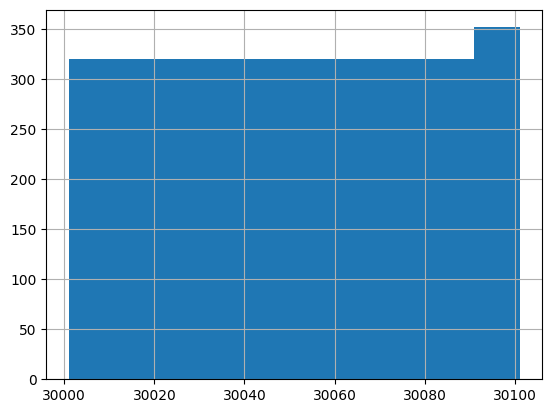

In [ ]:
# Histogram for numeric data
structured_data['Respondent ID'].hist()
plt.show()

Department
Department 1     13
Department 10     3
Department 11     3
Department 2     16
Department 3     13
Department 4     12
Department 5      5
Department 6      5
Department 7      2
Department 8     10
Department 9      1
No answer        18
Name: Respondent ID, dtype: int64


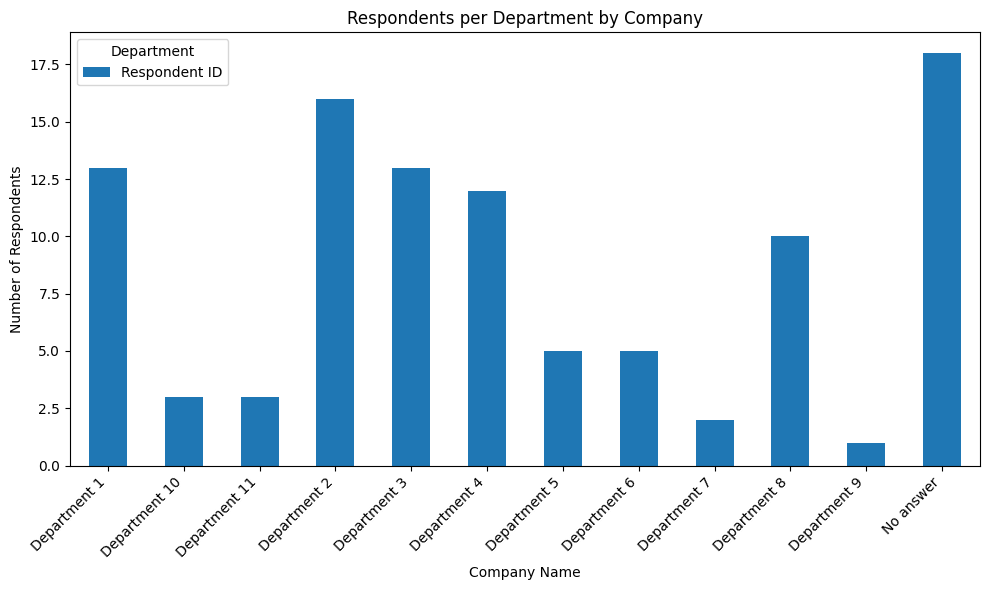

In [ ]:
# Exploring respondents by departments for each company

# Group data by department, then count respondents
respondent_counts_by_department = structured_data.groupby([ 'Department'])['Respondent ID'].nunique()
# Display the results
print(respondent_counts_by_department)

respondent_counts_by_department.plot(kind='bar', figsize=(10, 6))
plt.title('Respondents per Department by Company')
plt.xlabel('Company Name')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Department')
plt.tight_layout()
plt.show()

2.  Feature Selection
    *   Use statistical methods (e.g., correlation analysis, ANOVA).

In [ ]:
# Example: ANOVA (Analysis of Variance)
# Check if there's a significant difference in Wellbeing Score between departments
import statsmodels.formula.api as sm

# structured_data['Wellbeing_Score'] = structured_data['Answer'][structured_data['Question'] == '14. How in general you would assess your well-being in the company']
model = sm.ols('normalized_wellbeing_scores ~ C(Department)', data=structured_data).fit()
print(model.summary())

# Post-hoc analysis (Tukey's HSD) to identify which groups differ significantly
from statsmodels.stats.multicomp import pairwise_tukeyhsd

m_comp = pairwise_tukeyhsd(endog=structured_data['normalized_wellbeing_scores'], groups=structured_data['Department'], alpha=0.05)
m_comp

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


                                 OLS Regression Results                                
Dep. Variable:     normalized_wellbeing_scores   R-squared:                       0.022
Model:                                     OLS   Adj. R-squared:                 -0.040
Method:                          Least Squares   F-statistic:                    0.3583
Date:                         Mon, 09 Dec 2024   Prob (F-statistic):              0.875
Time:                                 12:50:20   Log-Likelihood:                -10.963
No. Observations:                           85   AIC:                             33.93
Df Residuals:                               79   BIC:                             48.58
Df Model:                                    5                                         
Covariance Type:                     nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------

2.  Feature Selection
      * Apply feature importance techniques if building models (e.g., decision trees).

<ipython-input-55-e1f8beb88bba>:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()
<ipython-input-55-e1f8beb88bba>:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


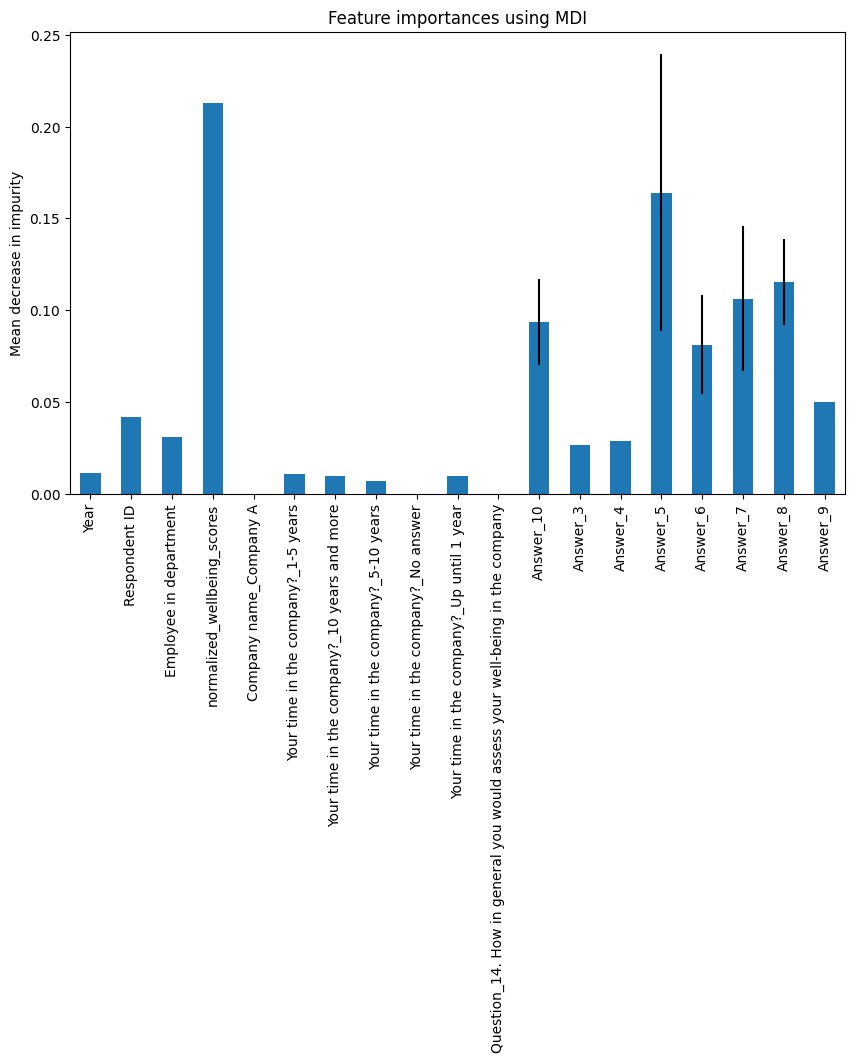

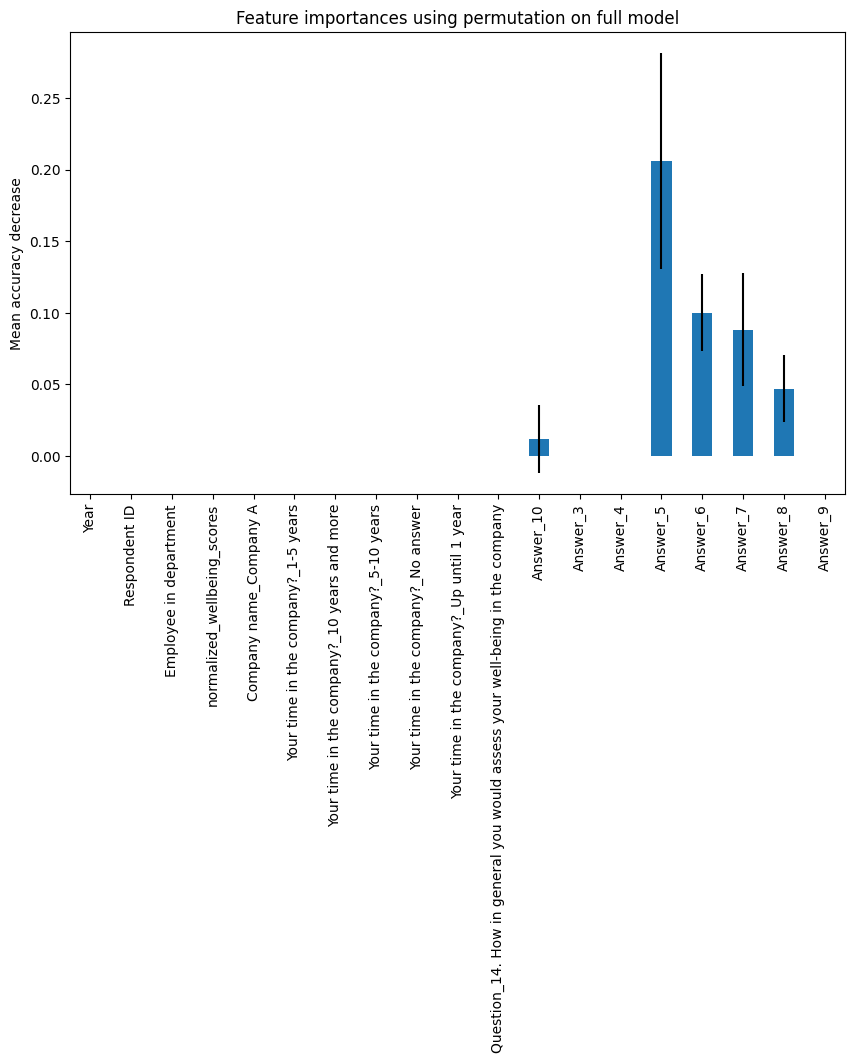

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder for categorical features

# Prepare data
X = structured_data.drop(['Department', 'wellbeing_scores'], axis=1)  # Features, remove target variable
y = structured_data['wellbeing_scores']  # Target variable

# Convert categorical features to numerical using OneHotEncoding
# Identify categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create OneHotEncoder object with sparse=False and handle_unknown='ignore'
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical features using the original X DataFrame
# This ensures that the encoded features have the same number of rows as the original data
encoded_features = encoder.fit_transform(X[categorical_features])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features), index=X.index) # Added index to align with X

# Replace original categorical features with encoded features
X = X.drop(categorical_features, axis=1)
X = pd.concat([X, encoded_df], axis=1)

# Now proceed with train-test split and model fitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Example using RandomForestClassifier (Decision Tree based)
model = RandomForestClassifier(n_estimators=100, random_state=42) # adjust parameters
model.fit(X_train, y_train)

# Feature importance from the model itself
importances = model.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names)

# Permutation Feature Importance
result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
forest_importances_permutation = pd.Series(result.importances_mean, index=feature_names)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

#Plot permutation feature importance
fig, ax = plt.subplots(figsize=(10,6))
forest_importances_permutation.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

3. Visual Exploration

    *   Use heatmaps to identify correlations between numerical features.
    *   Plot bar charts for categorical distributions (e.g., employee roles).
    *   Use word clouds to visualize common themes in textual feedback.

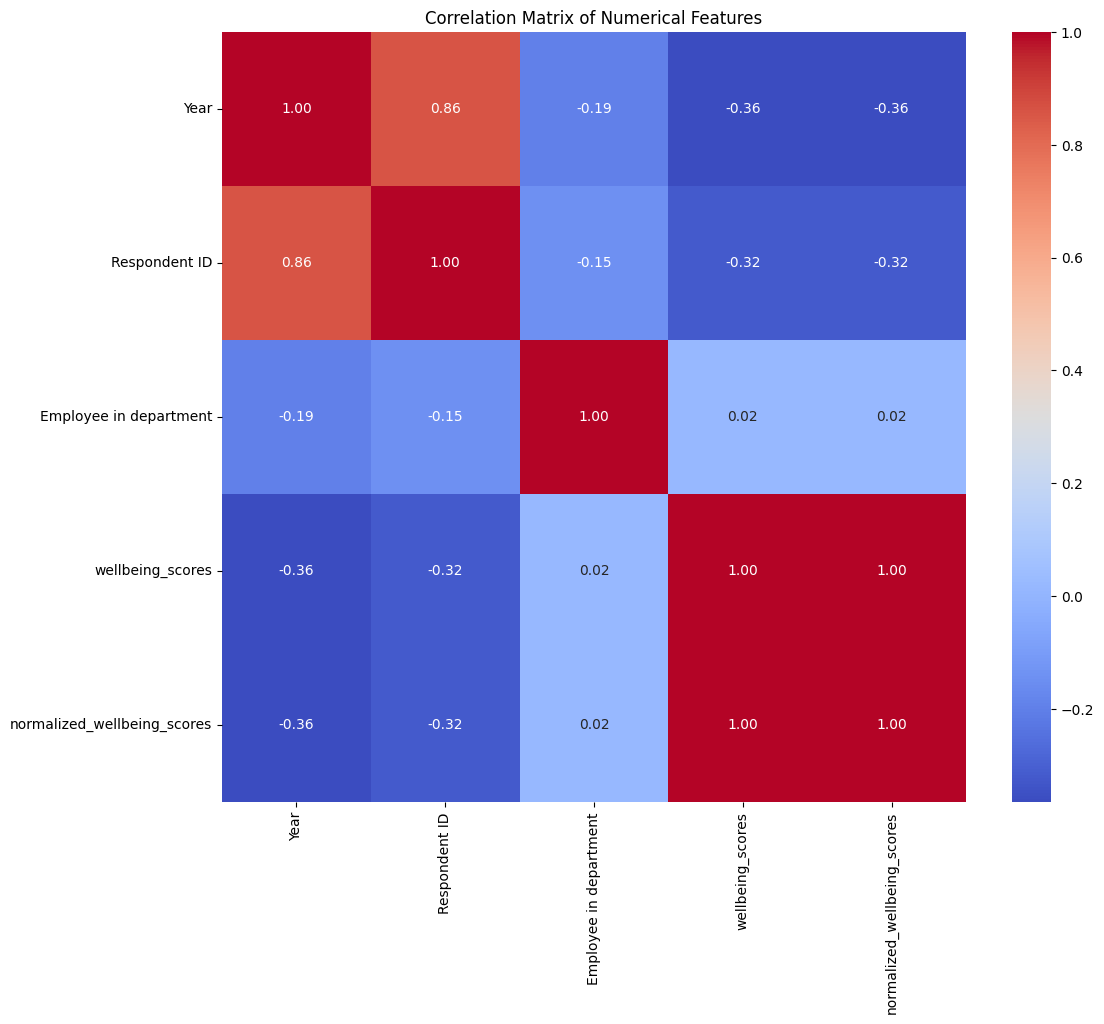

In [ ]:
# Use of heatmaps to identify correlations between numerical features.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features for correlation analysis
numerical_features = structured_data.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

4. Insights - focus on features with significant patterns, high correlations, or strong impact on the target variable.

<ipython-input-24-30b019dbc54d>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(structured_data, x='Respondent ID', y='Employee in department', inner='stick', palette='Dark2')


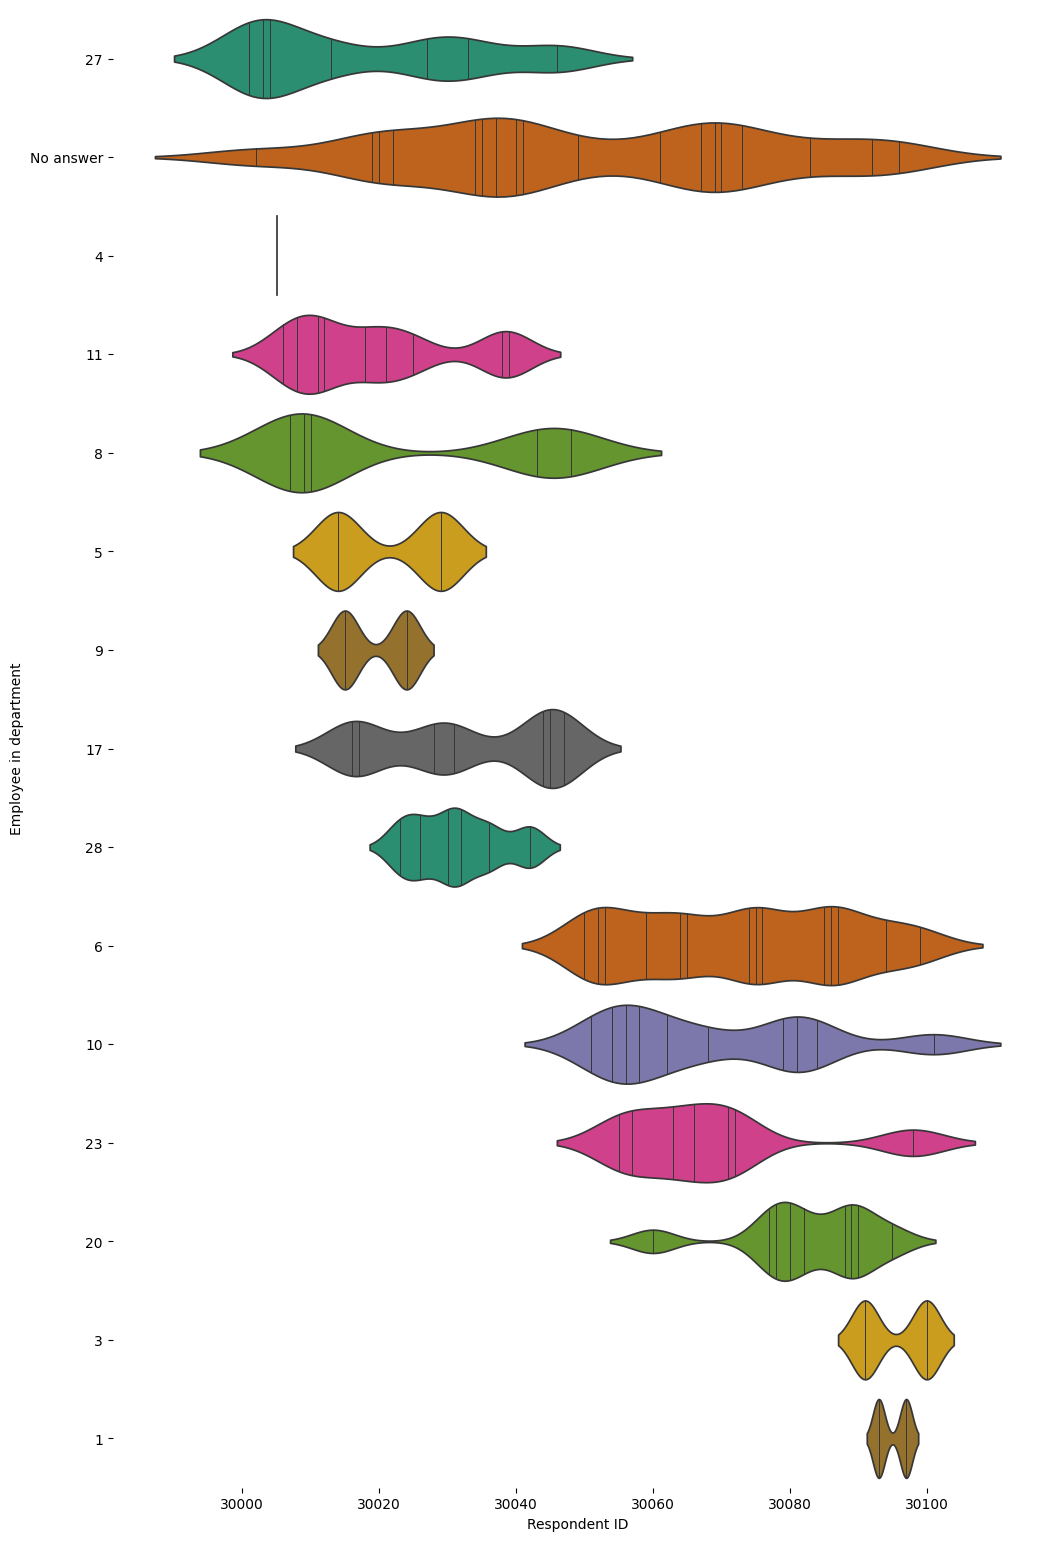

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(structured_data['Employee in department'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(structured_data, x='Respondent ID', y='Employee in department', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

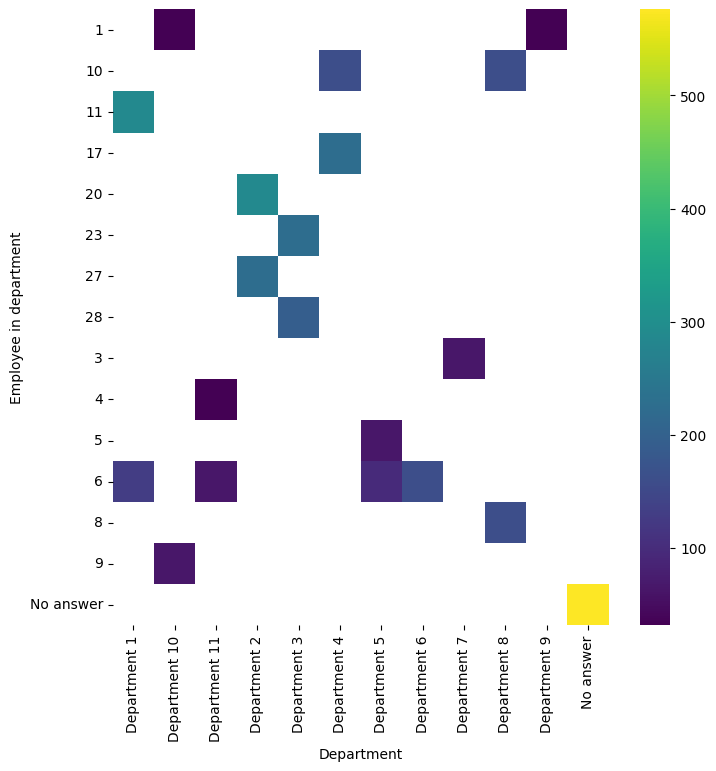

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Employee in department'].value_counts()
    for x_label, grp in structured_data.groupby('Department')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Department')
_ = plt.ylabel('Employee in department')


Feedback (Textual Data):
   Respondent ID                                           Question  \
0          30001              Comment about clearnes fo work duties   
1          30001         Comment about direct supervisor competence   
2          30001  Comment about evaluations of a job well done d...   
3          30001      Comment about information exchange in company   
4          30001  Comment about information for successful perfo...   

         Answer  
0     No answer  
1     No answer  
2     No answer  
3  Not included  
4     No answer  
count          1616
unique          194
top       No answer
freq           1263
Name: Answer, dtype: object
count    1616.000000
mean       14.740718
std        22.259299
min         3.000000
25%         9.000000
50%         9.000000
75%         9.000000
max       307.000000
Name: comment_length, dtype: float64


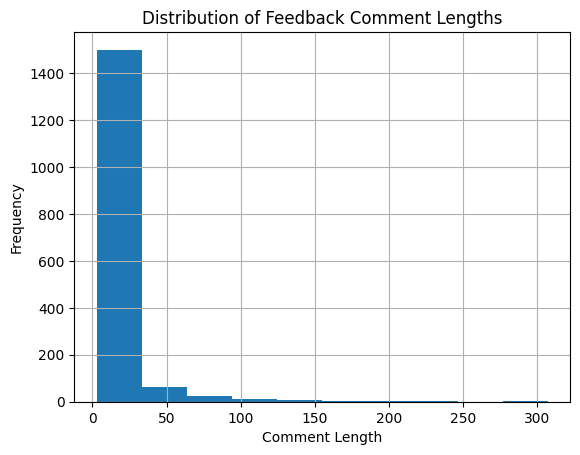

In [ ]:
# Feedback (Textual data from unstructured dataset)
print("\nFeedback (Textual Data):")
print(unstructured_data.head()) # Show the first few rows of the unstructured data
print(unstructured_data['Answer'].describe()) # Summary stats of the feedback column
# Analyze the length of feedback comments
unstructured_data['comment_length'] = unstructured_data['Answer'].astype(str).apply(len)
print(unstructured_data['comment_length'].describe())
unstructured_data['comment_length'].hist()
plt.title('Distribution of Feedback Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

count     101
unique      9
top         5
freq       23
Name: Answer, dtype: object


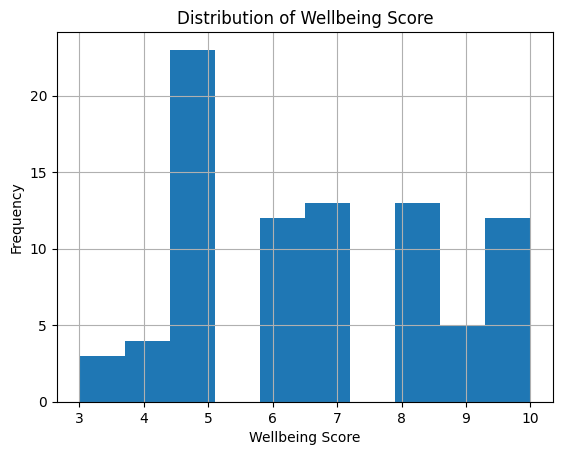

In [ ]:
# Question about wellbeing is in the 'Question' column and the score is in the 'Answer' column:
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

# Now can access the corresponding answers, which are the wellbeing scores
wellbeing_scores = wellbeing_data['Answer']

# Display the summary statistics
print(wellbeing_scores.describe())

# To convert the scores to numeric if they are not already
wellbeing_scores = pd.to_numeric(wellbeing_scores, errors='coerce')  # 'coerce' handles non-numeric values

# Create the histogram
wellbeing_scores.hist()
plt.title('Distribution of Wellbeing Score')
plt.xlabel('Wellbeing Score')
plt.ylabel('Frequency')
plt.show()

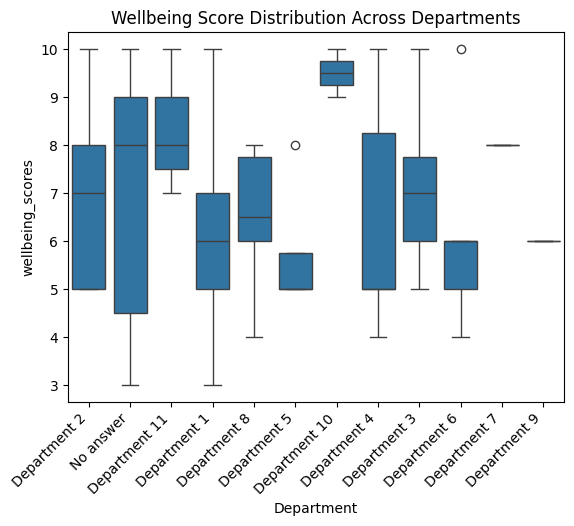

In [ ]:
# Explore relationship between department and wellbeing score

# 'Wellbeing Score' is the column to analyze
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

# Add the 'wellbeing_scores' as a column to the structured_data DataFrame
structured_data['wellbeing_scores'] = pd.to_numeric(wellbeing_data['Answer'], errors='coerce')

#Now you can use the 'wellbeing_scores' column for the boxplot:
sns.boxplot(x='Department', y='wellbeing_scores', data=structured_data)
plt.xticks(rotation=45, ha='right')
plt.title('Wellbeing Score Distribution Across Departments')
plt.show()

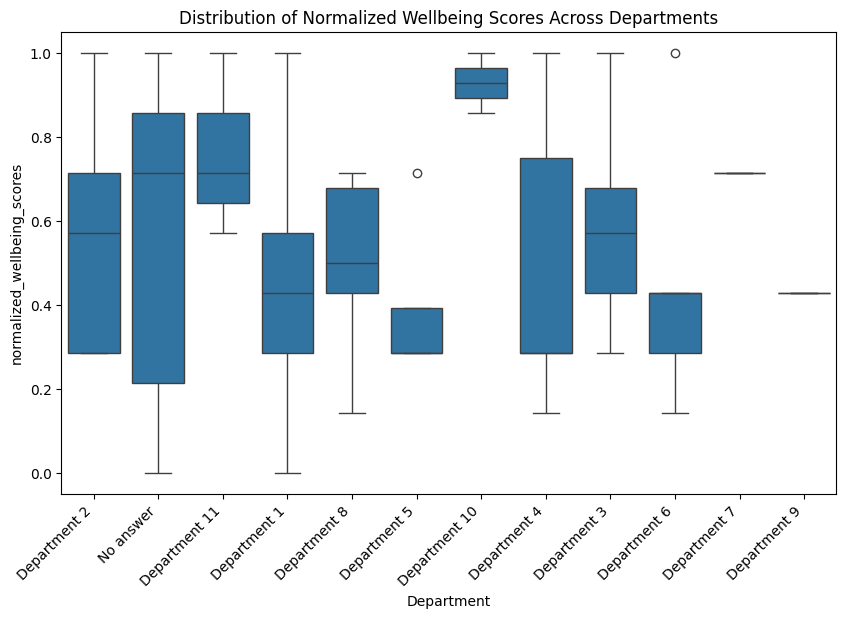

In [ ]:
# Improved Wellbeing Score Analysis
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

if not wellbeing_data.empty:
    wellbeing_scores = pd.to_numeric(wellbeing_data['Answer'], errors='coerce')
    wellbeing_scores = wellbeing_scores.dropna()

    # Normalization
    scaler = MinMaxScaler()
    normalized_wellbeing = scaler.fit_transform(wellbeing_scores.values.reshape(-1, 1))

    # Adding normalized scores back to the DataFrame
    structured_data['normalized_wellbeing_scores'] = np.nan
    # Index alignment for assignment
    structured_data.loc[wellbeing_scores.index, 'normalized_wellbeing_scores'] = normalized_wellbeing.flatten()

    #Analysis with normalized wellbeing scores
    #Example: Boxplot of normalized wellbeing score distribution across Departments
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Department', y='normalized_wellbeing_scores', data=structured_data)
    plt.title('Distribution of Normalized Wellbeing Scores Across Departments')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("No data found for the wellbeing question")

In [ ]:
# Find the answers to the stress question

stress_question = ['6.1. What causes you stress at work?', '6.2.  What causes you stress at work', '6.3. What causes you stress at work?','6.4. What causes you stress at work?', '6.5. What causes you stress at work?', '6.6. What causes you stress at work?']

for question in stress_question:
    stress_causes = structured_data[structured_data['Question'] == question]['Answer']
    # Check if any answers were found
    if not stress_causes.empty:
        # Display unique answers and their counts
        print(f"Answers for the question: '{question}'")
        print(stress_causes.value_counts())
        print("---")
    else:
        print(f"No answers found for the question: '{question}'")
        print("Please check if the question exists in your dataset and if the 'Question' and 'Answer' column names are correct.")
        print("---")

Answers for the question: '6.1. What causes you stress at work?'
Answer
Nothing causes                      34
Other                               16
Deadlines for completion of work    13
Colleagues                           8
Unclear work tasks, requirements     8
Scope of work                        8
Direct supervisor                    6
Company management                   5
No answer                            3
Name: count, dtype: int64
---
No answers found for the question: '6.2.  What causes you stress at work'
Please check if the question exists in your dataset and if the 'Question' and 'Answer' column names are correct.
---
Answers for the question: '6.3. What causes you stress at work?'
Answer
No answer                           85
Deadlines for completion of work     4
Direct supervisor                    3
Company management                   3
Scope of work                        2
Colleagues                           2
Other                                1
Unclear wor

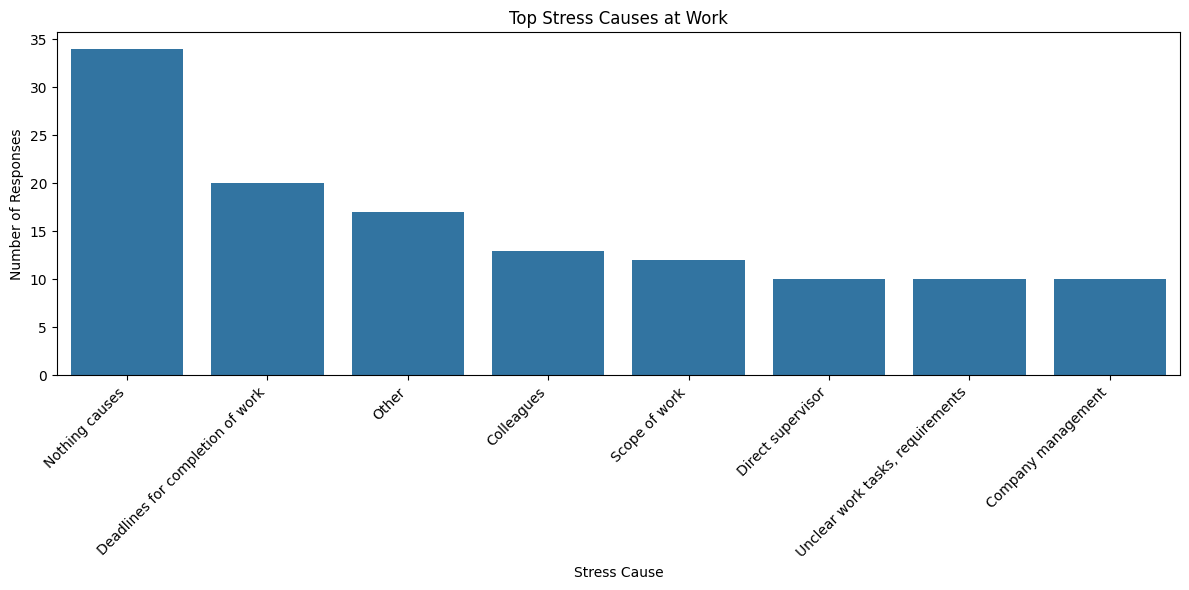

In [ ]:
# From structured_data questions  '6.1. What causes you stress at work?', '6.2.  What causes you stress at work', '6.3. What causes you stress at work?','6.4. What causes you stress at work?', '6.5. What causes you stress at work?', '6.6. What causes you stress at work?' And offer suitable visual presentation showing categorys, clean 'No answers'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Assuming 'structured_data' is your DataFrame

stress_questions = ['6.1. What causes you stress at work?', '6.2.  What causes you stress at work', '6.3. What causes you stress at work?', '6.4. What causes you stress at work?', '6.5. What causes you stress at work?', '6.6. What causes you stress at work?']
all_stress_causes = []

for question in stress_questions:
    stress_causes = structured_data[structured_data['Question'] == question]['Answer'].dropna()
    all_stress_causes.extend(stress_causes)

#Clean 'No answers'
all_stress_causes = [cause for cause in all_stress_causes if cause.lower() != 'no answer']

#Count the frequency of each stress cause
cause_counts = Counter(all_stress_causes)

#Create a DataFrame for better visualization
df_stress_causes = pd.DataFrame.from_dict(cause_counts, orient='index', columns=['Count'])
df_stress_causes.index.name = 'Stress Cause'
df_stress_causes = df_stress_causes.sort_values('Count', ascending=False) # Sort by frequency

#Visualize the top N stress causes using a bar plot
N = 10 # Number of top causes to display
plt.figure(figsize=(12,6))
sns.barplot(x=df_stress_causes.index[:N], y=df_stress_causes['Count'][:N])
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.title('Top Stress Causes at Work')
plt.xlabel('Stress Cause')
plt.ylabel('Number of Responses')
plt.tight_layout()
plt.show()

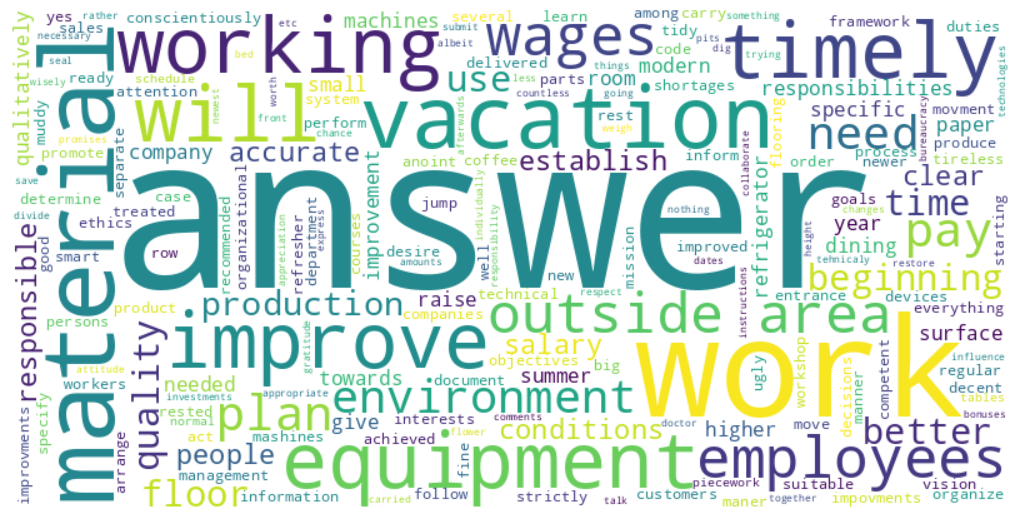

In [ ]:
# Visual representation of unstructured dataset filtering by
#'16. Your recommendations for improving the organization of the work process within the department or the entire enterprise in order to improve the result of the quality of work:'
# Load data
unstructured_data = pd.read_json('/content/WellBeing_Data_Unstructured.json')

#Lower case all text
unstructured_data['Answer'] = unstructured_data['Answer'].str.lower() # make lowercase

# Filter out rows where 'Answer' is 'No answer'
filtered_data = unstructured_data[unstructured_data['Answer'] != 'No answer']

# Relevant column is named 'Answer', adjust if necessary.
question_number = '16. Your recommendations for improving the organization of the work process within the department or the entire enterprise in order to improve the result of the quality of work:'

# Further filter for the specific question
filtered_data_16 = filtered_data[filtered_data['Question'] == question_number]

# Create your visual representation.  A word cloud is a good choice for this kind of data.
from wordcloud import WordCloud

# Combine all text responses into a single string
text = ' '.join(filtered_data_16['Answer'].astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

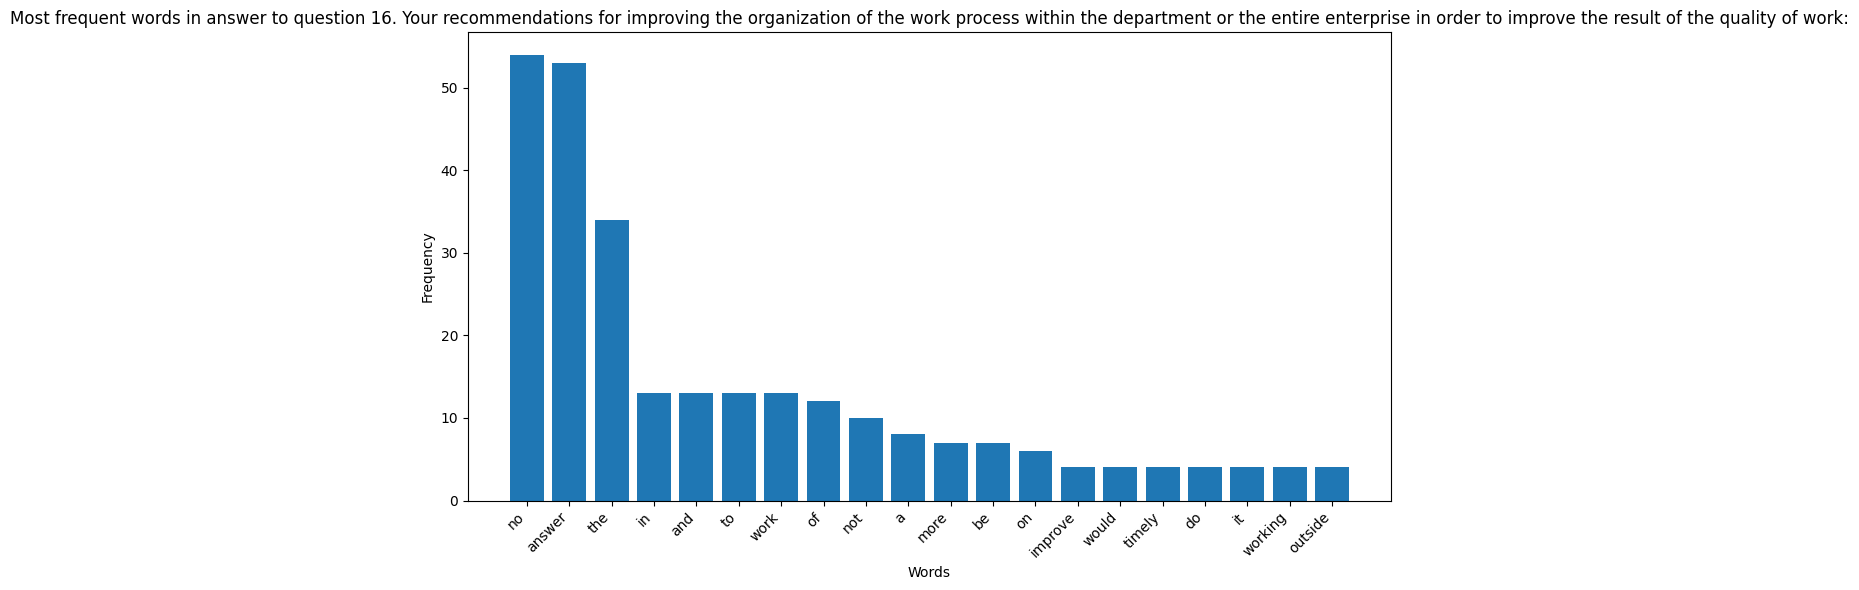

In [ ]:
# Visualization: Bar plot of the most frequent words

from collections import Counter

words = text.split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)  # Show the top 20 most frequent words

words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title(f"Most frequent words in answer to question {question_number}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Design

###Data Quality Improvement

1. Handling Missing Values

As author discovered before in this data set there is no missing values.

2. Data Type Correction






In [ ]:
# Replace 'No answer' with 0 and NaN with 0 before converting to integers
structured_data['Employee in department'] = structured_data['Employee in department'].fillna(0).replace('No answer', 0).astype(int)

structured_data.dtypes

,0
Company name,object
Year,float64
Respondent ID,float64
Department,object
Employee in department,int64
Your time in the company?,object
Question,object
Answer,object
wellbeing_scores,float64
normalized_wellbeing_scores,float64


In [ ]:
# Converting data type from Object to Categorical
# Identify columns with 'object' dtype
object_columns = structured_data.select_dtypes(include=['object']).columns

# Loop through the columns and convert them to categorical
for col in object_columns:
  structured_data[col] = pd.Categorical(structured_data[col])

# Now check the data types again:
structured_data.dtypes

,0
Company name,category
Year,float64
Respondent ID,float64
Department,category
Employee in department,int64
Your time in the company?,category
Question,category
Answer,category
wellbeing_scores,float64
normalized_wellbeing_scores,float64


3. Inconsistent Categories

For this data set author desided to code departments by using 'Departmen 1', 'Department 2' etc. this is done to keep orginal data anonimous. But for other cases Author suggest to clean data.

In [ ]:
#Example for 'department' category improvments:
#structured_data['Department'] = structured_data['Department'].str.lower().str.strip() # convert to lowercase, remove spaces
#structured_data['Department'] = structured_data['Department'].replace({'hr': 'human resources'})

4. Outlier Detection and Treatment

Identify outliers in numerical data using box plots, scatter plots or statistical methods like IQR (Interquartile Range)

In [ ]:
# Outlier Detection and Treatment
# Use box plots or IQR to detect outliers and decide on treatment (removal or capping)
#Example using IQR for numerical column 'wellbeing_scores' (adjust column names)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
structured_data = remove_outliers_iqr(structured_data, 'wellbeing_scores')

5. Text Cleaning (for unstructured data)

In [ ]:
#Text Cleaning (unstructured data)
unstructured_data['Answer'] = unstructured_data['Answer'].str.lower()

7. Data Validation

In [ ]:
# Validate data against known constraints (e.g., valid ranges for numerical values, acceptable categories).
# Flag or correct invalid values.

# Data Validation
def validate_data(df):
    """
    Validates data in the DataFrame against known constraints.
    Flags or corrects invalid values.
    """

    # Example 1: Validating 'wellbeing_scores' range
    valid_wellbeing_range = (1, 10)  # Assuming a valid range of 1-10

    invalid_wellbeing = df[~df['wellbeing_scores'].between(*valid_wellbeing_range)]

    if not invalid_wellbeing.empty:
      print("Invalid wellbeing scores found:")
      print(invalid_wellbeing[['wellbeing_scores']])

      # Options for handling:
      # 1. Remove invalid rows
      # df = df[df['wellbeing_scores'].between(*valid_wellbeing_range)]

      # 2. Replace invalid with NaN or a default value (e.g. median)
      median_wellbeing = df['wellbeing_scores'].median()
      df.loc[~df['wellbeing_scores'].between(*valid_wellbeing_range), 'wellbeing_scores'] = median_wellbeing

      # 3. Cap the values (set to minimum or maximum)
      # df.loc[df['wellbeing_scores'] < valid_wellbeing_range[0], 'wellbeing_scores'] = valid_wellbeing_range[0]
      # df.loc[df['wellbeing_scores'] > valid_wellbeing_range[1], 'wellbeing_scores'] = valid_wellbeing_range[1]

        # Example 2: Validating 'Department' categories
    valid_departments = ['Department 1', 'Department 2', 'Department 3', 'Department 4', 'Department 5']
    invalid_departments = df[~df['Department'].isin(valid_departments)]

    if not invalid_departments.empty:
      print("Invalid departments found:")
      print(invalid_departments['Department'].unique())

      # Check if 'Other' is already a category before adding it
      if 'Other' not in df['Department'].cat.categories:
          df['Department'] = df['Department'].cat.add_categories(['Other'])

      # Now you can safely assign 'Other'
      df.loc[~df['Department'].isin(valid_departments), 'Department'] = 'Other'


    return df

structured_data = validate_data(structured_data)

Invalid departments found:
['No answer', 'Department 11', 'Department 8', 'Department 10', 'Department 6', 'Department 7', 'Department 9']
Categories (12, object): ['Department 1', 'Department 10', 'Department 11', 'Department 2', ...,
                          'Department 7', 'Department 8', 'Department 9', 'No answer']


<ipython-input-39-e4ee9afd6b97>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Department'] = df['Department'].cat.add_categories(['Other'])


 9. Consistency across datasets (Structured and Unstructured):
- Ensure that employee IDs and other identifying information match across both datasets if you plan to merge or join the data.
- Employ appropriate techniques to align and consolidate relevant data points from both structured and unstructured sources.

In [ ]:
# Consistency across datasets (Structured and Unstructured):
# 'Respondent ID' is the common identifier
# Merge the datasets based on 'Respondent ID'
merged_data = pd.merge(structured_data, unstructured_data, on='Respondent ID', how='left')

# Check for inconsistencies in employee IDs
if not merged_data.empty:
    id_mismatches = merged_data[merged_data['Respondent ID'].isnull()]
    if not id_mismatches.empty:
        print("Inconsistencies found in Respondent IDs:")
        print(id_mismatches)
    else:
        print("No inconsistencies found in Respondent IDs.")
else:
    print("No data found in the merged dataset")

No inconsistencies found in Respondent IDs.


10. Check for inconsistencies in data:
- Standardize formats (also important in date/time data if have).

In [ ]:
# Inconsistent Categories
# Standardize categorical values (e.g., lowercase, remove whitespace)
for col in structured_data.select_dtypes(include='object'):
    structured_data[col] = structured_data[col].str.lower().str.strip()  # convert to lowercase and remove whitespace

11. Deduplication:
- Remove duplicate rows from both datasets, if any.

In [ ]:
#Remove duplicate rows from both datasets, if any.

# Remove duplicate rows from structured data
structured_data.drop_duplicates(inplace=True)

# Remove duplicate rows from unstructured data
unstructured_data.drop_duplicates(inplace=True)

<ipython-input-42-ae030801884a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  structured_data.drop_duplicates(inplace=True)


12. Normalizing of data

In [ ]:
# Question: How in general you would assess your well-being in the company with answers

# 'Wellbeing Score' is the column you want to analyze (replace if different)
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

# Check if wellbeing_data is empty
if wellbeing_data.empty:
    print("No data found for the specified wellbeing question. Check the question text.")
else:
    # Now you can access the corresponding answers, which are likely the wellbeing scores
    wellbeing_answers = wellbeing_data['Answer']

    # Display the unique answers and their counts
    print(wellbeing_answers.value_counts())

Answer
5                                                                                                         23
7                                                                                                         13
8                                                                                                         13
10                                                                                                        12
6                                                                                                         12
9                                                                                                          5
4                                                                                                          4
3                                                                                                          3
Salary                                                                                                     0
No informati

In [ ]:
# Question about wellbeing is in the 'Question' column and the score is in the 'Answer' column:
wellbeing_data = structured_data[structured_data['Question'] == '14. How in general you would assess your well-being in the company']

# Check if wellbeing_data is empty
if wellbeing_data.empty:
    print("No data found for the specified wellbeing question. Check the question text.")
else:
    # Now you can access the corresponding answers, which are likely the wellbeing scores
    wellbeing_scores = wellbeing_data['Answer']

    # Convert 'wellbeing_scores' to numeric, handling errors
    wellbeing_scores = pd.to_numeric(wellbeing_scores, errors='coerce')

    # Remove or replace non-numeric values (e.g., 'No answer')
    # Option 1: Remove rows with non-numeric values
    wellbeing_scores = wellbeing_scores.dropna()

    # Option 2: Replace non-numeric values with a specific value (e.g., 0)
    # wellbeing_scores = wellbeing_scores.fillna(0)

# 'Wellbeing Score' is the column we want to normalize
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Reshape the data before scaling (MinMaxScaler expects a 2D array)
wellbeing_scores_reshaped = wellbeing_scores.values.reshape(-1, 1)

# Fit and transform the data
normalized_wellbeing_scores = scaler.fit_transform(wellbeing_scores_reshaped)

# Convert back to a pandas Series if needed
normalized_wellbeing_scores = pd.Series(normalized_wellbeing_scores.flatten(), name='Normalized Wellbeing Score')

# Now we can use normalized_wellbeing_scores in your analysis
print(normalized_wellbeing_scores.describe())

count    85.000000
mean      0.532773
std       0.280036
min       0.000000
25%       0.285714
50%       0.571429
75%       0.714286
max       1.000000
Name: Normalized Wellbeing Score, dtype: float64


### Otology Generation

In [ ]:
# Ontology Generation
from rdflib import Graph, Namespace, RDF, RDFS, URIRef

# Step 1: Create a namespace for the ontology
namespace = Namespace("http://example.org/ontology#")

# Step 2: Initialize an RDF graph
g = Graph()

# Step 3: Define classes (entities)
g.add((namespace.Employee, RDF.type, RDFS.Class))
g.add((namespace.Department, RDF.type, RDFS.Class))
g.add((namespace.WellBeingMetric, RDF.type, RDFS.Class))

# Step 4: Define properties (relationships)
g.add((namespace.belongsTo, RDF.type, RDF.Property))
g.add((namespace.belongsTo, RDFS.domain, namespace.Employee))
g.add((namespace.belongsTo, RDFS.range, namespace.Department))

g.add((namespace.hasMetric, RDF.type, RDF.Property))
g.add((namespace.hasMetric, RDFS.domain, namespace.Employee))
g.add((namespace.hasMetric, RDFS.range, namespace.WellBeingMetric))

g.add((namespace.monitors, RDF.type, RDF.Property))
g.add((namespace.monitors, RDFS.domain, namespace.Department))
g.add((namespace.monitors, RDFS.range, namespace.WellBeingMetric))

# Step 5: Add individual instances (optional, from dataset)
employee_1 = URIRef("http://example.org/Employee/1")
department_1 = URIRef("http://example.org/Department/HR")
metric_1 = URIRef("http://example.org/Metric/Satisfaction")

g.add((employee_1, RDF.type, namespace.Employee))
g.add((employee_1, namespace.belongsTo, department_1))
g.add((employee_1, namespace.hasMetric, metric_1))

g.add((department_1, RDF.type, namespace.Department))
g.add((department_1, namespace.monitors, metric_1))

g.add((metric_1, RDF.type, namespace.WellBeingMetric))

# Step 6: Serialize the ontology to a file 'employee_wellbeing_ontology.rdf' to save in the current working directory
ontology_file = 'employee_wellbeing_ontology.rdf'
g.serialize(destination=ontology_file, format='xml')

print(f"Ontology saved to {ontology_file}")


Ontology saved to employee_wellbeing_ontology.rdf


##Implementation

###Big Data Management

In [ ]:
# If the datasets are extensive, leverage Dask – a parallel computing library that integrates with Pandas.

import dask.dataframe as dd

# For this 'structured_data' is large Pandas DataFrame
# Convert the Pandas DataFrame to a Dask DataFrame
dask_df = dd.from_pandas(structured_data, npartitions=4)  # Adjust npartitions as needed

# Now can perform operations on the Dask DataFrame in parallel
# Example: Calculate the mean of a column
mean_value = dask_df['wellbeing_scores'].mean().compute()  # .compute() triggers the computation

print(f"Mean wellbeing score (using Dask): {mean_value}")

Mean wellbeing score (using Dask): 6.729411764705882


###Cloud Computing Integration

In [ ]:
# Example deployment to AWS Lambda (Conceptual Outline)

# 1. Data Preparation:
#    - Preprocess the data (cleaning, feature engineering) in Colab.
#    - Save the preprocessed data to a cloud storage service (e.g., S3).

# 2. Model Training (Colab or other suitable environment):
#    - Train your chosen model (e.g., RandomForestClassifier, DecisionTreeClassifier).
#    - Save the trained model to a cloud storage service (e.g., S3).

# 3. AWS Lambda Function:
#    - Create a Lambda function in Python.
#    - This function will:
#       - Retrieve the model and preprocessed data from S3.
#       - Accept input data as part of the Lambda event.
#       - Use the loaded model to make predictions on the input data.
#       - Return the predictions.

# 4. API Gateway (Optional):
#    - Integrate the Lambda function with API Gateway to create a RESTful API endpoint for accessing predictions.

# Conceptual Python Code Snippet for the Lambda Function:

# import boto3  # AWS SDK for Python (Boto3)
# import pickle
# import pandas as pd
# import json # to handle the incoming JSON data

# s3 = boto3.client('s3')
# BUCKET_NAME = 'your-s3-bucket-name' # Replace with your S3 bucket name

# def lambda_handler(event, context):
#     try:
#         # Retrieve the model from S3
#         model_object = s3.get_object(Bucket=BUCKET_NAME, Key='your_model_file.pkl')
#         model = pickle.loads(model_object['Body'].read())

#         # Retrieve the preprocessed data from S3 (if needed for prediction)
#         # data_object = s3.get_object(Bucket=BUCKET_NAME, Key='your_data_file.csv')
#         # data = pd.read_csv(data_object['Body'])

#         # Get input data from the event (adjust as needed for Lambda input format)
#         input_data = json.loads(event['body']) # Assuming the event body is a JSON string
#         # input_data = event['queryStringParameters'] # Or another parameter in the Lambda event

#         # Make predictions using the model
#         # Note: The prediction code will depend on the format of input_data
#         # and the requirements of your model
#         predictions = model.predict(input_data) # Replace with the correct prediction logic

#         # Return the predictions
#         return {
#             'statusCode': 200,
#             'body': json.dumps({'predictions': predictions.tolist()}) # Convert predictions to a list
#         }

#     except Exception as e:
#         return {
#             'statusCode': 500,
#             'body': json.dumps({'error': str(e)})
#         }


In [ ]:
# # Example using Google Cloud Functions (Conceptual Outline)

# 1. Data Preparation:
#    - Same as AWS Lambda.

# 2. Model Training:
#    - Same as AWS Lambda.

# 3. Google Cloud Function:
#    - Create a Cloud Function in Python.
#    - This function will:
#       - Retrieve the model and preprocessed data from Cloud Storage (e.g., Google Cloud Storage).
#       - Accept input data as part of the Cloud Function's HTTP request.
#       - Use the loaded model to make predictions.
#       - Return the predictions.

# 4. Cloud Run (for more complex scenarios):
#    - If your function requires more resources or has more complex dependencies, consider deploying to Cloud Run.

# Conceptual Python code snippet for a Google Cloud Function:

# from google.cloud import storage
# import pickle

# def predict(request):
#     try:
#         # Retrieve model from Cloud Storage (GCS)
#         storage_client = storage.Client()
#         bucket_name = "your-gcs-bucket-name"  # Replace with your GCS bucket name
#         blob_name = "your_model_file.pkl"  # Replace with the model file path
#         bucket = storage_client.bucket(bucket_name)
#         blob = bucket.blob(blob_name)
#         model = pickle.loads(blob.download_as_bytes())
#         # ... (similar prediction logic as for AWS Lambda)
#         # ... (respond with JSON predictions)
#     except Exception as e:
#         return f"Error: {e}"

###Addressing Privacy and Trust

As this project dataset is already anonymized it is no need to assign this code, but for other cases Author prepared code example (just need to take of # from code lines)

In [ ]:
#Example code for removing Personally Identifiable Information
# Hash sensitive columns
#structured_data['email'] = structured_data['email'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
#structured_data['phone_number'] = structured_data['phone_number'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())

# Drop unnecessary PII columns
#structured_data.drop(['name', 'address'], axis=1, inplace=True)

# Save anonymized dataset
#structured_data.to_csv('/path/to/anonymized_dataset.csv', index=False)


*   **Generalize Sensitive Data** - replace specific data with broader categories (e.g., exact age → age range, ZIP codes → regions).

As this project dataset is already anonymized it is no need to assign this code, but for other cases Author prepared code example (just need to take of # from code lines)

In [ ]:
# Example code for Generalize Sensitive Data
#structured_data['age'] = structured_data['age'].apply(lambda x: f"{(x//10)*10}-{(x//10)*10+9}")



*   **Add Noise for Extra Privacy (Differential Privacy)** - it means to add random noise to numeric data to prevent exact identification.



As this project dataset is already anonymized it is no need to assign this code, but for other cases Author prepared code example (just need to take of # from code lines)

In [ ]:
# Adding noise to wellbeing score
#structured_data['Wellbeing_score'] = structured_data['Wellbeing_score'] + np.random.normal(0, 500, len(df))



*   **Tokenization** - it means replace sensitive information with tokens stored in a secure mapping table.



As this project dataset is already anonymized it is no need to assign this code, but for other cases Author prepared code example (just need to take of # from code lines)

In [ ]:
# Example of code for tokenization
#from faker import Faker
#fake = Faker()
#structured_data['email'] = structured_data['email'].apply(lambda _: fake.email())


2.   Data Encryption - data encryption ensures that sensitive data remains private during storage and transit.


*   Encrypt Data at Rest - use encryption algorithms like AES (Advanced Encryption Standard) to secure data stored in files or databases. After store the key securely in a key management service (e.g., AWS KMS, Google Cloud KMS)

In [ ]:
# Example of code how Encrypt Data at Rest
from cryptography.fernet import Fernet

# Generate a key
key = Fernet.generate_key()
cipher = Fernet(key)

# Encrypt a sample string
sensitive_data = b"Sensitive Information"
encrypted_data = cipher.encrypt(sensitive_data)

# Decrypt the data
decrypted_data = cipher.decrypt(encrypted_data)
print(decrypted_data.decode())

Sensitive Information


##Results and Discussion

See Project report added to this Google Colab Notebook.

##Conclusion

*   Ontology Framework - The developed ontology provided a structured representation of employee wellbeing data, enhancing data organization and integration. This framework improves semantic analysis, scalability, and AI system compatibility.
*   Privacy and Trust Measures - Privacy-preserving techniques like anonymization, encryption, and federated learning ensured secure and ethical data handling. These measures-built trust among stakeholders and complied with regulatory standards like GDPR.
* Machine Learning Success - Predictive models effectively identified patterns in employee well-being, demonstrating AI's potential in HR analytics. However, integrating Explainable AI (XAI) could improve model interpretability and stakeholder trust.
* Scalability and Real-World Application - AI solutions for employee wellbeing can revolutionize HR by providing actionable insights. Future work should focus on leveraging cloud technologies and advanced privacy methods to enhance scalability and adoption.


##References

1. Amazon Web Services, Inc., n.d. Define Lambda function handler in Python [WWW Document]. AWS. URL https://docs.aws.amazon.com/lambda/latest/dg/python-handler.html#python-best-practices (accessed 12.2.24).
2.	Cloud Storage Tutorial [WWW Document], n.d. . Google Cloud. URL https://cloud.google.com/functions/docs/tutorials/storage#functions-prepare-environment-python (accessed 12.2.24).
3.	Data and Beyond, n.d. . A blog on Data Science & Machine Learning for beginner. URL dataandbeyond.wordpress.com/2017/08/24/grid-search/ (accessed 12.2.24).
4.	Gabriel Suarez, 2023. ArticleAISupervisedLearning [WWW Document]. github. URL https://github.com/GabrielSB19/ArticleAISupervisedLearning (accessed 12.2.24).
5.	George, N., 2021. Practical Data Science with Python: Learn tools and techniques from hands-on examples to extract insights from data, 1st ed. Packt Publishing, Birmingham.
6.	Kelleher, J.D., Mac Namee, B., D’Arcy, A., 2020. Fundamentals of machine learning for predictive data analytics : algorithms, worked examples, and case studies., Second edition. ed. The MIT Press, Cambridge, Massachusetts.
7.	Ovh, 2020. Interpretability-engine [WWW Document]. github. URL https://github.com/ovh/interpretability-engine?tab=readme-ov-file (accessed 12.2.24).

